In [2]:
# Check what sheets and data are available in the Excel file
import pandas as pd

xlsx_path = "20251111_JUNCTION_training.xlsx"

xl_file = pd.ExcelFile(xlsx_path)
print("Available sheets:")
for sheet in xl_file.sheet_names:
    print(f"  - {sheet}")

print("\n" + "="*70)

# Check each sheet structure
for sheet in xl_file.sheet_names:
    df = pd.read_excel(xlsx_path, sheet_name=sheet)
    print(f"\n{sheet}:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    if 'measured_at' in df.columns:
        df['measured_at'] = pd.to_datetime(df['measured_at'])
        print(f"  Date range: {df['measured_at'].min()} to {df['measured_at'].max()}")
    print(f"  First few rows:")
    print(df.head(3).to_string(index=False))


Available sheets:
  - training_prices
  - training_consumption
  - training_data_2021_2024
  - Temperature
  - groups
  - Construction data
  - Industry data


training_prices:
  Shape: (32880, 2)
  Columns: ['measured_at', 'eur_per_mwh']
  Date range: 2021-01-01 00:00:00+00:00 to 2024-10-01 23:00:00+00:00
  First few rows:
              measured_at  eur_per_mwh
2021-01-01 00:00:00+00:00        24.35
2021-01-01 01:00:00+00:00        23.98
2021-01-01 02:00:00+00:00        23.72

training_prices:
  Shape: (32880, 2)
  Columns: ['measured_at', 'eur_per_mwh']
  Date range: 2021-01-01 00:00:00+00:00 to 2024-10-01 23:00:00+00:00
  First few rows:
              measured_at  eur_per_mwh
2021-01-01 00:00:00+00:00        24.35
2021-01-01 01:00:00+00:00        23.98
2021-01-01 02:00:00+00:00        23.72

training_consumption:
  Shape: (32856, 113)
  Columns: ['measured_at', 28, 29, 30, 36, 37, 38, 39, 40, 41, 42, 43, 73, 74, 76, 116, 149, 150, 151, 152, 157, 196, 197, 198, 199, 200, 201, 213, 22

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [29]:
xlsx_path = "20251111_JUNCTION_training.xlsx"

df_cons = pd.read_excel(xlsx_path, sheet_name="training_consumption")
df_cons["measured_at"] = pd.to_datetime(df_cons["measured_at"])
df_cons = df_cons.sort_values("measured_at").set_index("measured_at")

print("Hourly consumption shape:", df_cons.shape)

monthly_cons = df_cons.resample("MS").sum()
monthly_cons.columns = monthly_cons.columns.astype(str)

print("Monthly consumption shape:", monthly_cons.shape)
print("Number of groups:", len(monthly_cons.columns))

Hourly consumption shape: (32856, 112)
Monthly consumption shape: (45, 112)
Number of groups: 112


In [30]:
groups_df = pd.read_excel(xlsx_path, sheet_name="groups")
groups_df["group_id"] = groups_df["group_id"].astype(str)

meta_cols = [c for c in groups_df.columns if c != "group_id"]

def describe_group_row(row):
    parts = []
    for col in meta_cols:
        val = row[col]
        if pd.notna(val):
            parts.append(str(val))
    return " / ".join(parts)

group_desc = (
    groups_df
    .set_index("group_id")
    .apply(describe_group_row, axis=1)
    .to_dict()
)

In [31]:
# ============================
# Load all exogenous variables
# ============================

# 1. Hourly prices -> monthly mean price
df_prices = pd.read_excel(xlsx_path, sheet_name="training_prices")
df_prices["measured_at"] = pd.to_datetime(df_prices["measured_at"])
df_prices = df_prices.sort_values("measured_at").set_index("measured_at")
price_hourly = df_prices["eur_per_mwh"].astype(float)
monthly_price = price_hourly.resample("MS").mean()

# 2. Temperature and heating demand
df_temp = pd.read_excel(xlsx_path, sheet_name="training_data_2021_2024")
df_temp["measured_at"] = pd.to_datetime(df_temp["measured_at"])
df_temp = df_temp.sort_values("measured_at").set_index("measured_at")
# monthly_temp = df_temp["temperature_celsius"].resample("MS").mean()
monthly_heating = df_temp["heating_demand"].resample("MS").mean()

# # 3. Construction index
# df_construction = pd.read_excel(xlsx_path, sheet_name="Construction data")
# df_construction["measured_at"] = pd.to_datetime(df_construction["measured_at"])
# df_construction = df_construction.sort_values("measured_at").set_index("measured_at")
# monthly_construction = df_construction["Construction index "].astype(float).resample("MS").mean()

# # 4. Industry index
# df_industry = pd.read_excel(xlsx_path, sheet_name="Industry data")
# df_industry["measured_at"] = pd.to_datetime(df_industry["measured_at"])
# df_industry = df_industry.sort_values("measured_at").set_index("measured_at")
# monthly_industry = df_industry["Industry index"].astype(float).resample("MS").mean()

# Combine all exogenous variables into one DataFrame
exog_vars = pd.concat([
    monthly_price,
    # monthly_temp,
    monthly_heating,
    # monthly_construction,
    # monthly_industry
], axis=1, join="inner")
exog_vars.columns = ["price", "heating_demand"]#, "temperature", "construction_idx", "industry_idx"]

print("Exogenous variables shape:", exog_vars.shape)
print("Exogenous variables:")
print(exog_vars.head())
print(f"\nDate range: {exog_vars.index.min()} to {exog_vars.index.max()}")

Exogenous variables shape: (45, 2)
Exogenous variables:
                               price  heating_demand
measured_at                                         
2021-01-01 00:00:00+00:00  51.246411       24.480242
2021-02-01 00:00:00+00:00  57.095982       27.100595
2021-03-01 00:00:00+00:00  38.319019       20.676210
2021-04-01 00:00:00+00:00  36.833500       15.415278
2021-05-01 00:00:00+00:00  44.026245        9.265995

Date range: 2021-01-01 00:00:00+00:00 to 2024-09-01 00:00:00+00:00


In [48]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def compute_metrics(y_true, y_pred, label_prefix=""):
    return {
        f"{label_prefix}MAE": mean_absolute_error(y_true, y_pred),
        f"{label_prefix}RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{label_prefix}MAPE": mape(y_true, y_pred),
    }


def find_best_sarimax_params(train_y, exog_train, max_p=2, max_q=2, max_P=1, max_Q=1):
    """
    Grid search to find best SARIMAX parameters based on AIC.
    Tests combinations of (p,d,q) and (P,D,Q,12) parameters.
    """
    best_aic = np.inf
    best_params = ((1,1,1), (0,1,1,12))
    
    # Fix d=1 and D=1 for differencing (common for non-stationary series)
    d, D, s = 1, 1, 12
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            for P in range(max_P + 1):
                for Q in range(max_Q + 1):
                    try:
                        model = SARIMAX(
                            train_y,
                            exog=exog_train,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False,
                        )
                        res = model.fit(disp=False, maxiter=100)
                        
                        if res.aic < best_aic:
                            best_aic = res.aic
                            best_params = ((p, d, q), (P, D, Q, s))
                    except:
                        continue
    
    return best_params


def sarimax_backtest_last_year(series, exog_df,
                               order=(1,1,1),
                               seasonal_order=(0,1,1,12),
                               auto_tune=False,
                               use_log='auto'):
    """
    Backtest using the last 3 years of data:
      - first 2 years (24 months) -> train
      - last 1 year (12 months)   -> validation

    series:    monthly consumption for one group (pd.Series)
    exog_df:   DataFrame with exogenous variables (price, temp, etc.)
    auto_tune: if True, automatically find best parameters via grid search
    use_log:   'auto' (choose best), True (force on), False (force off)

    Returns: 
      - if auto_tune: val_true, sarimax_forecast, naive_forecast, (best_order, best_seasonal), use_log
      - else: val_true, sarimax_forecast, naive_forecast, use_log
    """
    # Align y and exog variables; drop any months where either is missing
    df_align = pd.concat([series, exog_df], axis=1, join="inner").dropna()
    
    if len(df_align) < 36:
        return None  # not enough history

    df_last36 = df_align.iloc[-36:]
    y_last36 = df_last36.iloc[:, 0]  # First column is the target
    exog_last36 = df_last36.iloc[:, 1:]  # Rest are exogenous variables

    # Train = first 24 months, validation = last 12 months
    train_y = y_last36.iloc[:24]
    val_true = y_last36.iloc[24:]
    exog_train = exog_last36.iloc[:24]
    exog_val = exog_last36.iloc[24:]

    # Auto-tune parameters first if requested (using no log initially)
    if auto_tune:
        best_order, best_seasonal = find_best_sarimax_params(train_y, exog_train)
    else:
        best_order, best_seasonal = order, seasonal_order

    # Auto-select log transformation based on validation performance with optimized params
    if use_log == 'auto' and (train_y > 0).all():
        # Try both transformations with the best parameters and pick the better one
        forecasts = {}
        mapes = {}
        for transform in [False, True]:
            try:
                if transform:
                    y_train = np.log(train_y)
                else:
                    y_train = train_y
                
                model = SARIMAX(y_train, exog=exog_train, order=best_order, 
                               seasonal_order=best_seasonal,
                               enforce_stationarity=False, enforce_invertibility=False)
                res = model.fit(disp=False, maxiter=50)
                fc = res.get_forecast(steps=12, exog=exog_val).predicted_mean
                
                if transform:
                    # Clip to prevent overflow when exponentiating
                    fc = np.clip(fc, -100, 100)
                    fc = np.exp(fc)
                
                forecasts[transform] = fc
                mapes[transform] = mape(val_true, fc.reindex(val_true.index))
            except:
                continue
        
        # Choose transformation with lower MAPE, but reject log if MAPE > 100% or if it's significantly worse
        if len(forecasts) == 2:
            mape_no_log = mapes[False]
            mape_log = mapes[True]
            # Use log only if: (1) MAPE is lower AND (2) MAPE < 100%
            use_log = (mape_log < mape_no_log) and (mape_log < 100.0)
        else:
            use_log = False
    elif use_log == 'auto':
        use_log = False
        # Still need to tune parameters
        if auto_tune:
            best_order, best_seasonal = find_best_sarimax_params(train_y, exog_train)
        else:
            best_order, best_seasonal = order, seasonal_order

    # Apply log transformation if selected
    if use_log and (train_y > 0).all():
        train_y_transformed = np.log(train_y)
    else:
        train_y_transformed = train_y
        use_log = False

    # SARIMAX with all exogenous variables (using already determined best_order, best_seasonal)
    model = SARIMAX(
        train_y_transformed,
        exog=exog_train,
        order=best_order,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)

    # Forecast the validation year
    res_fc = res.get_forecast(steps=12, exog=exog_val)
    val_forecast = res_fc.predicted_mean

    # Inverse transform if log was used
    if use_log:
        # Clip to prevent overflow when exponentiating
        val_forecast = np.clip(val_forecast, -100, 100)
        val_forecast = np.exp(val_forecast)

    # Naive baseline: same month last year (no exog)
    naive_forecast = series.shift(12).iloc[-12:]

    # Align outputs
    val_true = val_true.sort_index()
    val_forecast = val_forecast.reindex(val_true.index)
    naive_forecast = naive_forecast.reindex(val_true.index)

    if auto_tune:
        return val_true, val_forecast, naive_forecast, (best_order, best_seasonal), use_log
    return val_true, val_forecast, naive_forecast, use_log


def sarimax_forecast_next_year(series, exog_df,
                               order=(1,1,1),
                               seasonal_order=(0,1,1,12),
                               use_log=True,
                               horizon=12):
    """
    Train on FULL aligned history and forecast NEXT `horizon` months.
    Uses climatology (historical averages) for future exogenous variables.
    """
    # Align y and exog
    df_align = pd.concat([series, exog_df], axis=1, join="inner").dropna()
    
    y = df_align.iloc[:, 0]  # First column is the target
    exog = df_align.iloc[:, 1:]  # Rest are exogenous variables

    # Apply log transformation if requested (only if all values are positive)
    if use_log and (y > 0).all():
        y_transformed = np.log(y)
    else:
        y_transformed = y
        use_log = False  # Disable if data has non-positive values

    # Fit SARIMAX on full history
    model_full = SARIMAX(
        y_transformed,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res_full = model_full.fit(disp=False)

    # Build future exogenous variables via monthly climatology
    last_month = y.index.max()
    future_index = pd.date_range(
        last_month + pd.offsets.MonthBegin(1),
        periods=horizon,
        freq="MS"
    )

    # Create future exog DataFrame with climatology for each variable
    exog_future = pd.DataFrame(index=future_index, columns=exog.columns)
    
    for col in exog.columns:
        # Monthly climatology: average value for each month (1-12)
        col_clim = exog[col].groupby(exog.index.month).mean()
        for ts in future_index:
            exog_future.loc[ts, col] = col_clim[ts.month]
    
    exog_future = exog_future.astype(float)

    fc_res = res_full.get_forecast(steps=horizon, exog=exog_future)
    fut_forecast = fc_res.predicted_mean
    
    # Inverse transform if log was used
    if use_log:
        # Clip to prevent overflow when exponentiating
        fut_forecast = np.clip(fut_forecast, -100, 100)
        fut_forecast = np.exp(fut_forecast)
    
    fut_forecast.index = future_index

    return fut_forecast

In [49]:
VAL_YEARS = 1       # backtest horizon = 1 year
TRAIN_YEARS = 2     # backtest training window = 2 years (24 months)
FUT_HORIZON = 12    # next-year forecast

# Parameters optimization
AUTO_TUNE_PARAMS = True      # Automatically find best SARIMA parameters per group
FIXED_ORDER = (0, 1, 0)      # Used if AUTO_TUNE_PARAMS = False
FIXED_SEASONAL_ORDER = (0, 1, 1, 12)  # Used if AUTO_TUNE_PARAMS = False
USE_LOG_TRANSFORM = 'auto'   # Automatically choose best transformation per group

# Future index = 12 months after the last observed month
last_month = monthly_cons.index.max()
future_index = pd.date_range(last_month + pd.offsets.MonthBegin(1),
                             periods=FUT_HORIZON, freq="MS")

forecast_df = pd.DataFrame(index=future_index,
                           columns=monthly_cons.columns,
                           dtype="float64")

metrics_rows = []
future_forecasts = {}
if AUTO_TUNE_PARAMS:
    print(f"Running SARIMAX with AUTO-TUNED parameters per group")
else:
    print(f"Running SARIMAX with fixed parameters: order={FIXED_ORDER}, seasonal_order={FIXED_SEASONAL_ORDER}")
print(f"Log transformation: {USE_LOG_TRANSFORM}")
print(f"Using exogenous variables: {list(exog_vars.columns)}")
print(f"Processing {len(monthly_cons.columns)} groups...\n")

log_transform_used = []
optimized_params = {}

for i, gid in enumerate(monthly_cons.columns, 1):
    series = monthly_cons[gid].dropna()

    # Backtest: last 3y (2y train, 1y val) with all exogenous variables
    bt = sarimax_backtest_last_year(series, exog_vars, 
                                     order=FIXED_ORDER, 
                                     seasonal_order=FIXED_SEASONAL_ORDER,
                                     auto_tune=AUTO_TUNE_PARAMS,
                                     use_log=USE_LOG_TRANSFORM)
    if bt is None:
        print(f"[{i}/{len(monthly_cons.columns)}] Group {gid}: SKIPPED - not enough history (< 36 months)")
        continue

    if AUTO_TUNE_PARAMS:
        val_true, sarimax_val_forecast, naive_val_forecast, (best_order, best_seasonal), used_log = bt
        optimized_params[gid] = (best_order, best_seasonal)
    else:
        val_true, sarimax_val_forecast, naive_val_forecast, used_log = bt
        optimized_params[gid] = (FIXED_ORDER, FIXED_SEASONAL_ORDER)
    
    log_transform_used.append(used_log)

    # Check for invalid forecasts (inf/nan)
    if not np.isfinite(sarimax_val_forecast).all():
        print(f"[{i}/{len(monthly_cons.columns)}] Group {gid}: SKIPPED - forecast contains invalid values (inf/nan)")
        continue

    # Metrics on the validation year
    sarimax_metrics = compute_metrics(val_true, sarimax_val_forecast, label_prefix="sarimax_")
    naive_metrics = compute_metrics(val_true, naive_val_forecast, label_prefix="naive_")

    row = {"group_id": gid, "used_log_transform": used_log}
    if AUTO_TUNE_PARAMS:
        row["order"] = str(best_order)
        row["seasonal_order"] = str(best_seasonal)
    row.update(sarimax_metrics)
    row.update(naive_metrics)
    metrics_rows.append(row)
    
    # Print error metrics for this group
    log_marker = "📊" if used_log else "📈"
    param_str = f"{optimized_params[gid][0]}{optimized_params[gid][1]}" if AUTO_TUNE_PARAMS else ""
    print(f"[{i}/{len(monthly_cons.columns)}] Group {gid} {log_marker} {param_str}:")
    print(f"  SARIMAX -> MAE: {sarimax_metrics['sarimax_MAE']:.2f}, "
          f"RMSE: {sarimax_metrics['sarimax_RMSE']:.2f}, "
          f"MAPE: {sarimax_metrics['sarimax_MAPE']:.2f}%")
    print(f"  Naive   -> MAE: {naive_metrics['naive_MAE']:.2f}, "
          f"RMSE: {naive_metrics['naive_RMSE']:.2f}, "
          f"MAPE: {naive_metrics['naive_MAPE']:.2f}%")

    # Final model: full history + all exog vars -> next-year forecast
    best_order, best_seasonal = optimized_params[gid]
    fut_forecast = sarimax_forecast_next_year(series, exog_vars, 
                                               order=best_order, 
                                               seasonal_order=best_seasonal,
                                               use_log=used_log,
                                               horizon=FUT_HORIZON)
    future_forecasts[gid] = fut_forecast
    
    # Populate forecast DataFrame
    forecast_df[gid] = fut_forecast

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_rows)

print("\n" + "="*70)
print("✓ Processing complete!")

# Check if metrics_df has any rows before accessing columns
if len(metrics_df) > 0:
    print(f"Average SARIMAX MAPE: {metrics_df['sarimax_MAPE'].mean():.2f}%")
    print(f"Average Naive MAPE: {metrics_df['naive_MAPE'].mean():.2f}%")
    print(f"Improvement: {metrics_df['naive_MAPE'].mean() - metrics_df['sarimax_MAPE'].mean():.2f}% points")
    
    # Log transform statistics
    log_count = sum(log_transform_used)
    print(f"\nLog transformation used for {log_count}/{len(log_transform_used)} groups ({100*log_count/len(log_transform_used):.1f}%)")

    # Show worst performing groups
    print("\n" + "="*70)
    print("Top 5 WORST groups by SARIMAX MAPE:")
    worst_groups = metrics_df.nlargest(5, 'sarimax_MAPE')[['group_id', 'sarimax_MAPE', 'sarimax_MAE', 'sarimax_RMSE']]
    for idx, row in worst_groups.iterrows():
        print(f"  Group {row['group_id']}: MAPE={row['sarimax_MAPE']:.2f}%, "
              f"MAE={row['sarimax_MAE']:.2f}, RMSE={row['sarimax_RMSE']:.2f}")

    print("\nTop 5 BEST groups by SARIMAX MAPE:")
    best_groups = metrics_df.nsmallest(5, 'sarimax_MAPE')[['group_id', 'sarimax_MAPE', 'sarimax_MAE', 'sarimax_RMSE']]
    for idx, row in best_groups.iterrows():
        print(f"  Group {row['group_id']}: MAPE={row['sarimax_MAPE']:.2f}%, "
              f"MAE={row['sarimax_MAE']:.2f}, RMSE={row['sarimax_RMSE']:.2f}")
else:
    print("No groups were successfully processed. All groups were skipped due to insufficient data.")

Running SARIMAX with AUTO-TUNED parameters per group
Log transformation: auto
Using exogenous variables: ['price', 'heating_demand']
Processing 112 groups...

[1/112] Group 28 📊 (0, 1, 0)(0, 1, 1, 12):
  SARIMAX -> MAE: 136.35, RMSE: 171.32, MAPE: 4.92%
  Naive   -> MAE: 807.22, RMSE: 1136.77, MAPE: 15.68%
[1/112] Group 28 📊 (0, 1, 0)(0, 1, 1, 12):
  SARIMAX -> MAE: 136.35, RMSE: 171.32, MAPE: 4.92%
  Naive   -> MAE: 807.22, RMSE: 1136.77, MAPE: 15.68%
[2/112] Group 29 📊 (0, 1, 0)(0, 1, 1, 12):
  SARIMAX -> MAE: 24.00, RMSE: 24.86, MAPE: 18.88%
  Naive   -> MAE: 9.37, RMSE: 10.80, MAPE: 7.01%
[2/112] Group 29 📊 (0, 1, 0)(0, 1, 1, 12):
  SARIMAX -> MAE: 24.00, RMSE: 24.86, MAPE: 18.88%
  Naive   -> MAE: 9.37, RMSE: 10.80, MAPE: 7.01%
[3/112] Group 30 📊 (0, 1, 0)(0, 1, 1, 12):
  SARIMAX -> MAE: 53.68, RMSE: 61.42, MAPE: 10.15%
  Naive   -> MAE: 120.66, RMSE: 173.59, MAPE: 13.75%
[3/112] Group 30 📊 (0, 1, 0)(0, 1, 1, 12):
  SARIMAX -> MAE: 53.68, RMSE: 61.42, MAPE: 10.15%
  Naive   -> MAE

In [47]:
# Export metrics and raw forecast (you can later convert to submission format)
metrics_df.to_csv("sarima_backtest_2year_train_1year_test_metrics.csv",
                  sep=";", decimal=",", index=False)  # European format

forecast_out = forecast_df.copy()
forecast_out.insert(0, "measured_at", forecast_out.index)

forecast_out.to_csv("sarima_next_year_forecast_raw.csv",
                    index=False, sep=";", decimal=",")


In [52]:
GROUP_ID = None
GROUP_INDEX = 0

Using group: 28


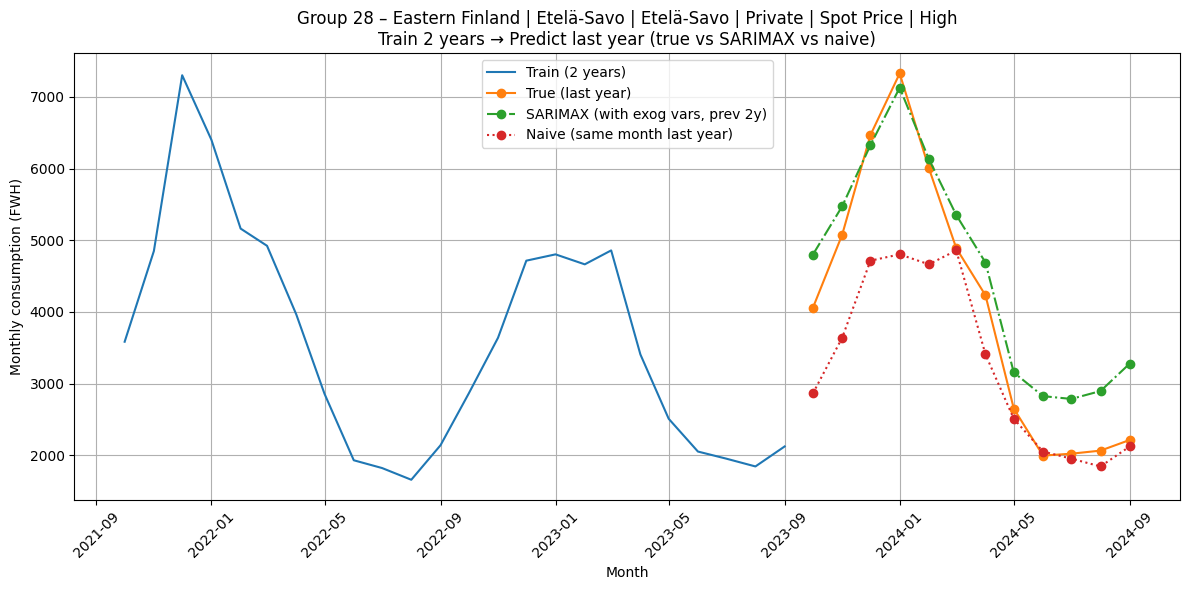

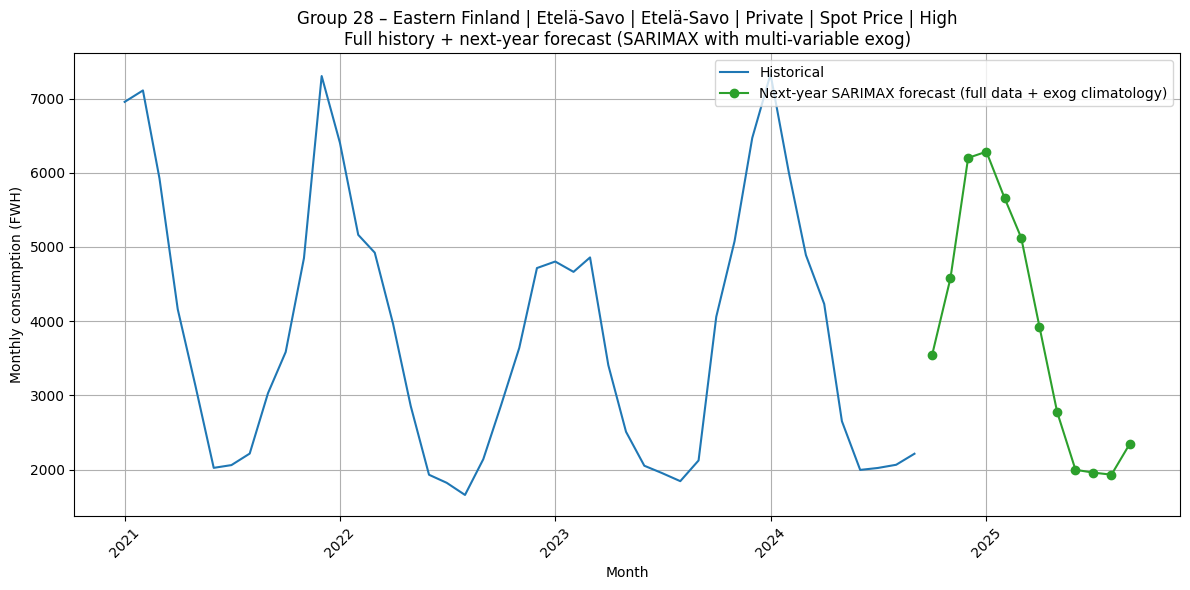

In [53]:
AVAILABLE_GROUPS = list(monthly_cons.columns)

# Convert GROUP_ID to string if it's not None (columns are strings)
TARGET_GROUP_ID = str(GROUP_ID) if GROUP_ID is not None else AVAILABLE_GROUPS[GROUP_INDEX]
print("Using group:", TARGET_GROUP_ID)

series = monthly_cons[TARGET_GROUP_ID].dropna()
bt = sarimax_backtest_last_year(series, exog_vars)

if bt is None:
    raise ValueError("Not enough aligned history for backtest for this group.")

val_true, sarimax_val_forecast, naive_val_forecast, used_log = bt

# Last 3 years (training 2y + validation 1y), aligned with exog
df_align = pd.concat([series, exog_vars], axis=1, join="inner").dropna()
df_last36 = df_align.iloc[-36:]

train_part = df_last36.iloc[:24, 0]  # First column is consumption
val_part = df_last36.iloc[24:, 0]  # equals val_true

plt.figure(figsize=(12, 6))

plt.plot(train_part.index, train_part.values,
         label="Train (2 years)", color="C0")
plt.plot(val_true.index, val_true.values,
         marker="o", linestyle="-", label="True (last year)", color="C1")
plt.plot(sarimax_val_forecast.index, sarimax_val_forecast.values,
         marker="o", linestyle="-.", label="SARIMAX (with exog vars, prev 2y)", color="C2")
plt.plot(naive_val_forecast.index, naive_val_forecast.values,
         marker="o", linestyle=":", label="Naive (same month last year)", color="C3")

desc = group_desc.get(TARGET_GROUP_ID, "No description")

plt.title(
    f"Group {TARGET_GROUP_ID} – {desc}\n"
    "Train 2 years → Predict last year (true vs SARIMAX vs naive)"
)
plt.xlabel("Month")
plt.ylabel("Monthly consumption (FWH)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Full history + next-year forecast
fut_forecast = future_forecasts[TARGET_GROUP_ID]

plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, label="Historical", color="C0")
plt.plot(fut_forecast.index, fut_forecast.values,
         marker="o", linestyle="-",
         label="Next-year SARIMAX forecast (full data + exog climatology)", color="C2")

plt.title(
    f"Group {TARGET_GROUP_ID} – {desc}\n"
    "Full history + next-year forecast (SARIMAX with multi-variable exog)"
)

plt.xlabel("Month")
plt.ylabel("Monthly consumption (FWH)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [54]:
# Analyze why predictions are too high for group 390
print(f"Group {TARGET_GROUP_ID} analysis:\n")

# Historical statistics
print(f"Full historical data:")
print(f"  Mean: {series.mean():.2f}")
print(f"  Max: {series.max():.2f}")
print(f"  Min: {series.min():.2f}")

# Training period
print(f"\nTraining period (2 years):")
print(f"  Mean: {train_part.mean():.2f}")
print(f"  Max: {train_part.max():.2f}")

# Validation period
print(f"\nValidation period (actual last year):")
print(f"  Mean: {val_true.mean():.2f}")
print(f"  Max: {val_true.max():.2f}")

# SARIMAX forecast
print(f"\nSARIMAX forecast (with log transform):")
print(f"  Mean: {sarimax_val_forecast.mean():.2f}")
print(f"  Max: {sarimax_val_forecast.max():.2f}")
print(f"  Overprediction: {((sarimax_val_forecast.mean() / val_true.mean()) - 1) * 100:.1f}%")

# Demonstrate log transform amplification
print(f"\n⚠️ Log transform amplification effect:")
train_max = train_part.max()
print(f"  Train max: {train_max:.2f}")
print(f"  Train max (in log): {np.log(train_max):.4f}")
print(f"  If model predicts +0.3 in log space → {np.exp(np.log(train_max) + 0.3):.2f} (×{np.exp(0.3):.2f})")
print(f"  If model predicts +0.5 in log space → {np.exp(np.log(train_max) + 0.5):.2f} (×{np.exp(0.5):.2f})")
print(f"  If model predicts +0.7 in log space → {np.exp(np.log(train_max) + 0.7):.2f} (×{np.exp(0.7):.2f})")
print(f"\n  This exponential amplification causes overestimation!")

Group 28 analysis:

Full historical data:
  Mean: 3814.07
  Max: 7327.94
  Min: 1657.84

Training period (2 years):
  Mean: 3584.40
  Max: 7302.83

Validation period (actual last year):
  Mean: 4083.68
  Max: 7327.94

SARIMAX forecast (with log transform):
  Mean: 4570.36
  Max: 7129.08
  Overprediction: 11.9%

⚠️ Log transform amplification effect:
  Train max: 7302.83
  Train max (in log): 8.8960
  If model predicts +0.3 in log space → 9857.79 (×1.35)
  If model predicts +0.5 in log space → 12040.33 (×1.65)
  If model predicts +0.7 in log space → 14706.10 (×2.01)

  This exponential amplification causes overestimation!
